In [3]:
from sequenceHandler import mapPDBToSequence
pdb_file = "5PTI.pdb"
chain_id = "A"
fasta_file = "rcsb_pdb_5PTI.fasta"
seq_mapping_file = "None"        
output_map_file = "distance_map.txt"  

dm, pdb_seq, residues = mapPDBToSequence(pdb_file, chain_id, fasta_file, seq_mapping_file, output_map_file)

print(dm)

[[ 0.          1.32672858  3.49029531 ...  2.35004763  3.25549231
   4.60219054]
 [ 1.32672858  0.          1.32328037 ...  5.82871529  8.397861
  11.59053592]
 [ 3.49029531  1.32328037  0.         ... 10.35822205 12.61087372
  14.91790678]
 ...
 [ 2.35004763  5.82871529 10.35822205 ...  0.          1.31645377
   4.84864095]
 [ 3.25549231  8.397861   12.61087372 ...  1.31645377  0.
   1.36155448]
 [ 4.60219054 11.59053592 14.91790678 ...  4.84864095  1.36155448
   0.        ]]


In [27]:
from sequenceHandler import mapPDBToHMM
pdb_file = "1AAL.pdb"
chain_id = "A"
hmm_file = "PF00014.hmm"
hmm_file_2 = "None"        
output_map_file = "distance_map.txt"  

dm,mi = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='all')
print(dm)
print(mi)

c:\Users\gfabi\miniconda3\envs\Internship\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 1359.
  warnings.warn(
c:\Users\gfabi\miniconda3\envs\Internship\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 1417.
  warnings.warn(


[<Residue ARG het=  resseq=1 icode= >, <Residue PRO het=  resseq=2 icode= >, <Residue ASP het=  resseq=3 icode= >, <Residue PHE het=  resseq=4 icode= >, <Residue CYS het=  resseq=5 icode= >, <Residue LEU het=  resseq=6 icode= >, <Residue GLU het=  resseq=7 icode= >, <Residue PRO het=  resseq=8 icode= >, <Residue PRO het=  resseq=9 icode= >, <Residue TYR het=  resseq=10 icode= >, <Residue THR het=  resseq=11 icode= >, <Residue GLY het=  resseq=12 icode= >, <Residue PRO het=  resseq=13 icode= >, <Residue CYS het=  resseq=14 icode= >, <Residue LYS het=  resseq=15 icode= >, <Residue ALA het=  resseq=16 icode= >, <Residue ARG het=  resseq=17 icode= >, <Residue ILE het=  resseq=18 icode= >, <Residue ILE het=  resseq=19 icode= >, <Residue ARG het=  resseq=20 icode= >, <Residue TYR het=  resseq=21 icode= >, <Residue PHE het=  resseq=22 icode= >, <Residue TYR het=  resseq=23 icode= >, <Residue ASN het=  resseq=24 icode= >, <Residue ALA het=  resseq=25 icode= >, <Residue LYS het=  resseq=26 icod

In [25]:
str='DYKDDDDKLKPDFCFLEEDPGICRGYITRYFYNNQTKQCERFKYGGCLGNMNNFETLEECKNICEDGPNGF'
print(len(str))
print(len(mi))
print(dm[33,10])

71
53
3.440397344032615


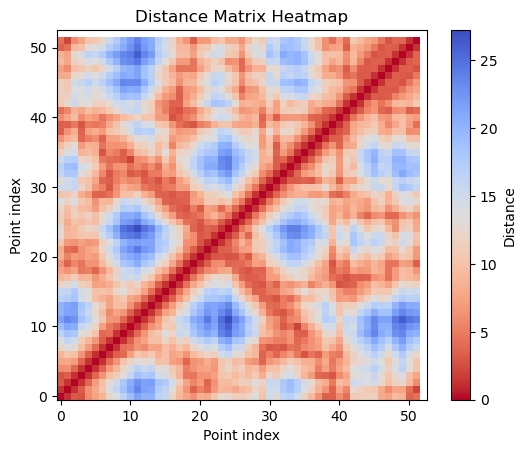

In [28]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(dm,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Distance")
plt.title("Distance Matrix Heatmap")
plt.xlabel("Point index")
plt.ylabel("Point index")

plt.show()

In [3]:
import requests
def get_pfam_msa(pfam_acc: str, kind: str = "seed") -> bytes:
    """
    kind: 'seed' (curato, ~decine/centinaia di seq)
    'full' (tutte le sequenze UniProt che matchano l'HMM, può essere enorme)
    """
    url = (
        f"https://www.ebi.ac.uk/interpro/wwwapi//"
        f"entry/pfam/{pfam_acc}/?annotation=alignment:{kind}"
    )
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()
    return resp.content  # formato Stockholm (.sto)

# Esempi
# seed = get_pfam_msa("PF00042", kind="seed")   # seed alignment - solo alcune sequenze buon usato per trainare hmm o per check
# full = get_pfam_msa("PF00042", kind="full")    # full alignment - tutto quello che sta su interpro

# Poi: salva lo .sto row-wise o passa in funzione che processa row-wise e converte
if False:
    out = 'percorso/nomefile.sto'
    with open(out, "w") as f:
        f.write(fasta)
    print(f"     Salvato in '{out}'")

In [17]:
pfam_id = "PF00042"
msa = get_pfam_msa(pfam_id, kind="full")
out = f'C:/Users/gfabi/Desktop/Internship/MSA/msa_{pfam_id}.sto'
with open(out, "wb") as f:
    f.write(msa)


In [18]:
from sequenceHandler import stockholm2fasta,filterSequenceByGapContent  
out_1= f'C:/Users/gfabi/Desktop/Internship/MSA/msa_{pfam_id}.fasta'
from sequenceHandler import stockholm2fasta,filterSequenceByGapContent  
stockholm2fasta(out,out_1)
filterSequenceByGapContent(out_1, 0.2, out_1)

Original number of sequences  20705
Sequences after filtering :  18268
Filtered sequences saved to  C:/Users/gfabi/Desktop/Internship/MSA/msa_PF00042.fasta


In [3]:
#DCA with Julia
import numpy as np 
import subprocess

#X = plmdca("C:/Users/gfabi/Desktop/Internship/DCA_model/PF00014_noinsert_max02gap.faa")

julia_code = """
using PlmDCA, DelimitedFiles
X = plmdca("C:/Users/gfabi/Desktop/Internship/MSA/msa_PF00014.fasta")
writedlm("scores.csv", X.score, ',')
"""

subprocess.run(["julia", "-e", julia_code])

data = np.loadtxt("scores.csv", delimiter=",")
print(data.shape)
# data columns: i, j, score
i = data[:, 0].astype(int)
j = data[:, 1].astype(int)
s = data[:, 2]

# Build matrix
N = int(max(i.max(), j.max()))
score_map = np.zeros((N, N))

for ii, jj, val in zip(i, j, s):
    score_map[ii-1, jj-1] = val
    score_map[jj-1, ii-1] = val

(1378, 3)


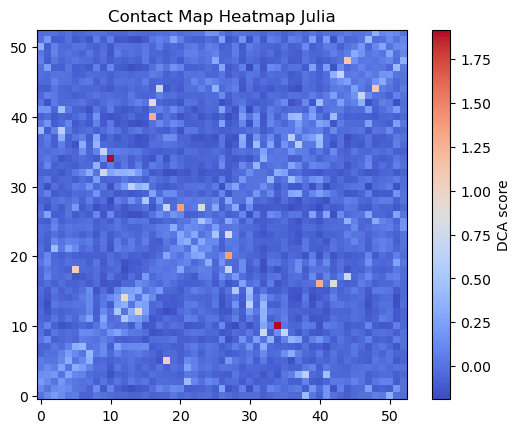

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(score_map,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA score")
plt.title("Contact Map Heatmap Julia")
plt.show()

In [10]:
def extract_scop_ids(sto_file_path):
    scop_ids = []

    with open(sto_file_path, "r") as f:
        for line in f:
            line = line.strip()

            # Look for SCOP annotation lines
            if line.startswith("#=GF DR") and "SCOP;" in line:
                parts = line.split(";")

                # Expected format:
                # #=GF DR   SCOP; 5pti; fa;
                if len(parts) >= 2:
                    scop_id = parts[1].strip()
                    scop_ids.append(scop_id)
    if scop_ids == []:
        print("No sequences with SCOP annotation found in the .sto file.")
    return scop_ids

In [ ]:

import requests


pfam_id = "PF00014"
out_0 = f'C:/Users/gfabi/Desktop/Internship/MSA/msa_{pfam_id}.sto'

pdb_id = extract_scop_ids(out_0)
print(pdb_id)
resp = requests.get(url=f"https://files.rcsb.org/download/{pdb_id[0].upper()}.pdb")
out_pdb = f'C:/Users/gfabi/Desktop/Internship/PDB/{pfam_id}.pdb'
with open(out_pdb, "wb") as f:
    f.write(resp.content)


['5pti']


In [ ]:


pdb_id = "5pti"
url = f"https://files.rcsb.org/download/{pdb_id.upper()}.pdb"

resp = requests.get(url)

with open(f"{pdb_id}_1.pdb", "wb") as f:
    f.write(resp.content)

In [15]:
import requests
import gzip
import shutil
import subprocess
import os

# -----------------------------
# 1. Download Pfam HMM database
# -----------------------------
url = "http://ftp.ebi.ac.uk/pub/databases/Pfam/current_release/Pfam-A.hmm.gz"
gz_path = "Pfam-A.hmm.gz"
hmm_path = "Pfam-A.hmm"

if not os.path.exists(gz_path):
    print("Downloading Pfam HMM database...")
    resp = requests.get(url, stream=True)
    with open(gz_path, "wb") as f:
        for chunk in resp.iter_content(chunk_size=8192):
            f.write(chunk)
else:
    print("Gz file already exists.")

# -----------------------------
# 2. Unzip the .gz file
# -----------------------------
if not os.path.exists(hmm_path):
    print("Unzipping...")
    with gzip.open(gz_path, "rb") as f_in:
        with open(hmm_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
else:
    print("HMM file already exists.")

# -----------------------------
# 3. Extract specific family
# -----------------------------
pfam_id = "PF00042"
output_hmm = f"{pfam_id}.hmm"

print(f"Extracting {pfam_id}...")

subprocess.run([
    "hmmfetch",
    hmm_path,
    pfam_id,
    "-o",
    output_hmm
])

print(f"Saved to {output_hmm}")

Gz file already exists.
HMM file already exists.
Extracting PF00042...
Saved to PF00042.hmm


In [14]:
# -----------------------------
# 3. Extract specific family
# -----------------------------
pfam_id = "PF00014"
out_hmm = f'C:/Users/gfabi/Desktop/Internship/HMM/{pfam_id}.hmm'

print(f"Extracting {pfam_id}...")

subprocess.run([
    "hmmfetch",
    hmm_path,
    pfam_id,
    "-o",
    output_hmm
])

print(f"Saved to {output_hmm}")

Extracting PF00014...
Saved to PF00014.hmm


In [2]:
import subprocess
pfam_id = "PF00014"

# Use Linux-style paths for WSL
hmm_path = "/mnt/c/Users/gfabi/Desktop/Internship/HMM/Pfam-A.hmm"
output_hmm = f"/mnt/c/Users/gfabi/Desktop/Internship/HMM/{pfam_id}.hmm"

print(f"Extracting {pfam_id}...")

subprocess.run([
    "wsl",  
    "hmmfetch",
    hmm_path,
    pfam_id,
    "-o",
    output_hmm
])

print(f"Saved to {output_hmm}")

Extracting PF00014...
Saved to /mnt/c/Users/gfabi/Desktop/Internship/HMM/PF00014.hmm


In [5]:
import subprocess

pfam_id = "PF00014"

hmm_path = "/mnt/c/Users/gfabi/Desktop/Internship/HMM/Pfam-A.hmm"
output_hmm = f"/mnt/c/Users/gfabi/Desktop/Internship/HMM/{pfam_id}.hmm"

print(f"Extracting {pfam_id}...")

result = subprocess.run(
    ["wsl", "hmmfetch", hmm_path, pfam_id, "-o", output_hmm],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(f"Saved to {output_hmm}")
else:
    print("Error:", result.stderr)

import os

if result.returncode == 0:
    if os.path.exists("C:/Users/gfabi/Desktop/Internship/HMM/" + pfam_id + ".hmm"):
        print(f"Saved to {output_hmm}")
    else:
        print("Command ran, but file was NOT created ⚠️")
else:
    print("Error:", result.stderr)

Extracting PF00014...
Error: Incorrect number of command line arguments.

Error: Incorrect number of command line arguments.



In [6]:
import subprocess

pfam_id = "PF00014"
hmm_path = "/mnt/c/Users/gfabi/Desktop/Internship/HMM/Pfam-A.hmm"

# Find full ID inside WSL
cmd = f"grep -m 1 {pfam_id} {hmm_path} | awk '{{print $2}}'"
res = subprocess.run(["wsl", "bash", "-c", cmd], capture_output=True, text=True)

full_id = res.stdout.strip()

print("Resolved ID:", full_id)

Resolved ID: ACC   PF00014.29


In [5]:
from __future__ import annotations

import gzip
import re
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import requests


BASE = "https://www.ebi.ac.uk/interpro/api"
TIMEOUT = 60


def _norm(s: str) -> str:
    return re.sub(r"\s+", " ", s.strip().lower())


def _extract_entry_fields(item: Dict[str, Any]) -> Tuple[str, str, str]:
    """
    Try to extract accession, short name, and description from an InterPro entry item.
    The API response shape can vary slightly over time, so this is defensive.
    """
    accession = (
        item.get("accession")
        or item.get("id")
        or item.get("metadata", {}).get("accession")
        or ""
    )

    short_name = (
        item.get("short_name")
        or item.get("name")
        or item.get("metadata", {}).get("short_name")
        or item.get("metadata", {}).get("name")
        or ""
    )

    description = (
        item.get("description")
        or item.get("metadata", {}).get("description")
        or ""
    )

    # Sometimes description may be a list of objects
    if isinstance(description, list) and description:
        first = description[0]
        if isinstance(first, dict):
            description = first.get("text") or first.get("value") or str(first)
        else:
            description = str(first)

    return str(accession), str(short_name), str(description)


def search_pfam_entries(query: str, page_size: int = 100) -> List[Dict[str, Any]]:
    """
    Search Pfam entries by text. Returns raw result objects.
    """
    url = f"{BASE}/entry/pfam"
    params = {"search": query, "page_size": page_size}
    results: List[Dict[str, Any]] = []

    while url:
        r = requests.get(url, params=params, timeout=TIMEOUT)
        r.raise_for_status()
        data = r.json()

        batch = data.get("results") or data.get("data") or []
        if not isinstance(batch, list):
            raise RuntimeError(f"Unexpected response shape: {type(batch)}")

        results.extend(batch)

        url = data.get("next")
        params = None  # next already includes query string if provided

    return results


def pick_best_pfam_match(query: str, entries: List[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Prefer exact matches on short name / accession, otherwise first reasonable hit.
    """
    q = _norm(query)

    scored: List[Tuple[int, Dict[str, Any]]] = []
    for item in entries:
        accession, short_name, description = _extract_entry_fields(item)
        a = _norm(accession)
        n = _norm(short_name)
        d = _norm(description)

        score = 1000
        if a == q:
            score = 0
        elif n == q:
            score = 1
        elif q in n:
            score = 2
        elif q in d:
            score = 3
        elif q in a:
            score = 4

        scored.append((score, item))

    if not scored:
        raise ValueError(f"No Pfam entries found for query: {query!r}")

    scored.sort(key=lambda x: x[0])
    return scored[0][1]


def download_pfam_hmm(accession: str, out_path: str | Path) -> Path:
    """
    Download the compressed HMM for a Pfam accession from InterPro.
    """
    out_path = Path(out_path)
    url = f"{BASE}/entry/pfam/{accession}"
    params = {"annotation": "hmm"}

    with requests.get(url, params=params, stream=True, timeout=TIMEOUT) as r:
        r.raise_for_status()
        out_path.parent.mkdir(parents=True, exist_ok=True)
        with open(out_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 64):
                if chunk:
                    f.write(chunk)

    return out_path


def fetch_pfam_hmm_by_name(
    family_name: str,
    output_dir: str | Path = ".",
    decompress: bool = False,
) -> Path:
    """
    Search a Pfam family by name and download its HMM.

    Returns the path to either:
      - *.hmm.gz  (default)
      - *.hmm     (if decompress=True)
    """
    matches = search_pfam_entries(family_name)
    best = pick_best_pfam_match(family_name, matches)

    accession, short_name, description = _extract_entry_fields(best)
    if not accession:
        raise RuntimeError("Could not determine Pfam accession from search result.")

    output_dir = Path(output_dir)
    gz_path = output_dir / f"{accession}.hmm.gz"
    download_pfam_hmm(accession, gz_path)

    if not decompress:
        return gz_path

    hmm_path = output_dir / f"{accession}.hmm"
    with gzip.open(gz_path, "rb") as fin, open(hmm_path, "wb") as fout:
        fout.write(fin.read())

    return hmm_path


if __name__ == "__main__":
    # Example: use a family name, not accession
    path = fetch_pfam_hmm_by_name(
        "phospholipase A2",
        output_dir="pfam_hmms",
        decompress=True,
    )
    print(f"Saved to: {path}")

SSLError: HTTPSConnectionPool(host='www.ebi.ac.uk', port=443): Max retries exceeded with url: /interpro/api/entry/pfam/PF00068?annotation=hmm (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1081)')))

In [7]:
from pathlib import Path
import gzip
import shutil
import subprocess
import sys

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


def _make_session():
    session = requests.Session()
    retry = Retry(
        total=5,
        connect=5,
        read=5,
        status=5,
        backoff_factor=1.0,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=frozenset(["GET"]),
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry, pool_connections=1, pool_maxsize=1)
    session.mount("https://", adapter)
    session.headers.update(
        {
            "User-Agent": "Mozilla/5.0",
            "Connection": "close",
            "Accept": "*/*",
        }
    )
    return session


def download_pfam_hmm(accession: str, out_dir: str = ".") -> Path:
    accession = accession.strip().upper()

    if not accession.startswith("PF") or len(accession) != 7:
        raise ValueError("Expected a Pfam accession like PF00042")

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    gz_path = out_dir / f"{accession}.hmm.gz"
    hmm_path = out_dir / f"{accession}.hmm"

    url = f"https://www.ebi.ac.uk/interpro/api/entry/pfam/{accession}?annotation=hmm"

    # First try pure Python requests with retries
    try:
        session = _make_session()
        with session.get(url, stream=True, timeout=(20, 120)) as r:
            r.raise_for_status()
            with open(gz_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=1024 * 64):
                    if chunk:
                        f.write(chunk)

    except requests.exceptions.SSLError:
        # Fallback: use curl if available, which often succeeds where requests/OpenSSL fails
        curl = shutil.which("curl") or shutil.which("curl.exe")
        if not curl:
            raise RuntimeError(
                "SSL error from requests, and curl was not found on PATH."
            )

        cmd = [
            curl,
            "-L",
            "--fail",
            "--retry",
            "5",
            "--retry-delay",
            "2",
            "--connect-timeout",
            "20",
            "-o",
            str(gz_path),
            url,
        ]
        subprocess.run(cmd, check=True)

    # Decompress .gz -> .hmm
    with gzip.open(gz_path, "rb") as fin, open(hmm_path, "wb") as fout:
        shutil.copyfileobj(fin, fout)

    return hmm_path


if __name__ == "__main__":
    path = download_pfam_hmm("PF00014", out_dir="hmms")
    print(path)

hmms\PF00014.hmm


In [11]:
from pathlib import Path
import gzip
import shutil
import subprocess

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


def _make_session():
    session = requests.Session()
    retry = Retry(
        total=5,
        connect=5,
        read=5,
        status=5,
        backoff_factor=1.0,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=frozenset(["GET"]),
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry, pool_connections=1, pool_maxsize=1)
    session.mount("https://", adapter)
    session.headers.update(
        {
            "User-Agent": "Mozilla/5.0",
            "Connection": "close",
            "Accept": "*/*",
        }
    )
    return session



accession = "PF00042"
out_dir="HMM"
accession = accession.strip().upper()

if not accession.startswith("PF") or len(accession) != 7:
    raise ValueError("Expected a Pfam accession like PF00042")

out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

gz_path = out_dir / f"{accession}.hmm.gz"
hmm_path = out_dir / f"{accession}.hmm"

url = f"https://www.ebi.ac.uk/interpro/api/entry/pfam/{accession}?annotation=hmm"

# First try pure Python requests with retries
try:
    session = _make_session()
    with session.get(url, stream=True, timeout=(20, 120)) as r:
        r.raise_for_status()
        with open(gz_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 64):
                if chunk:
                    f.write(chunk)

except requests.exceptions.SSLError:
    # Fallback: use curl if available, which often succeeds where requests/OpenSSL fails
    curl = shutil.which("curl") or shutil.which("curl.exe")
    if not curl:
        raise RuntimeError(
            "SSL error from requests, and curl was not found on PATH."
        )

    cmd = [
        curl,
        "-L",
        "--fail",
        "--retry",
        "5",
        "--retry-delay",
        "2",
        "--connect-timeout",
        "20",
        "-o",
        str(gz_path),
        url,
    ]
    subprocess.run(cmd, check=True)

# Decompress .gz -> .hmm
with gzip.open(gz_path, "rb") as fin, open(hmm_path, "wb") as fout:
    shutil.copyfileobj(fin, fout)



In [6]:
from sequenceHandler import mapPDBToHMM
pdb_file = f"C:/Users/gfabi/Desktop/Internship/PDB/PF00014.pdb"
chain_id = "A"
hmm_file = f"C:/Users/gfabi/Desktop/Internship/HMM/PF00014.hmm"
hmm_file_2 = "None"        
output_map_file = "None" 

distance_map,map_index,aligned_sequence = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='all')
#print(distance_map)
print(map_index)
print(aligned_sequence)

c:\Users\gfabi\miniconda3\envs\Internship\Lib\site-packages\Bio\PDB\Atom.py:237: PDBConstructionWarning: Used element 'U' for Atom (name=UNK) with given element 'X'
  warnings.warn(msg, PDBConstructionWarning)


[<Residue ARG het=  resseq=1 icode= >, <Residue PRO het=  resseq=2 icode= >, <Residue ASP het=  resseq=3 icode= >, <Residue PHE het=  resseq=4 icode= >, <Residue CYS het=  resseq=5 icode= >, <Residue LEU het=  resseq=6 icode= >, <Residue GLU het=  resseq=7 icode= >, <Residue PRO het=  resseq=8 icode= >, <Residue PRO het=  resseq=9 icode= >, <Residue TYR het=  resseq=10 icode= >, <Residue THR het=  resseq=11 icode= >, <Residue GLY het=  resseq=12 icode= >, <Residue PRO het=  resseq=13 icode= >, <Residue CYS het=  resseq=14 icode= >, <Residue LYS het=  resseq=15 icode= >, <Residue ALA het=  resseq=16 icode= >, <Residue ARG het=  resseq=17 icode= >, <Residue ILE het=  resseq=18 icode= >, <Residue ILE het=  resseq=19 icode= >, <Residue ARG het=  resseq=20 icode= >, <Residue TYR het=  resseq=21 icode= >, <Residue PHE het=  resseq=22 icode= >, <Residue TYR het=  resseq=23 icode= >, <Residue ASN het=  resseq=24 icode= >, <Residue ALA het=  resseq=25 icode= >, <Residue LYS het=  resseq=26 icod

In [9]:
alph = list('ACDEFGHIKLMNPQRSTVWY')

def one_hot(sequence, alphabet=alph):
  vector = []
  for letter in sequence:
    temp = [0 if char != letter else 1 for char in alphabet]
    vector.append(temp)
  return vector

import pickle

pfam_id = "PF00042"
with open(f"Data/data_{pfam_id}.pkl", "rb") as f:
    loaded = pickle.load(f)

sequence=loaded['sequence'] 
distance_map=loaded['distance_map']
contact_map_DCA=loaded['dca']


In [10]:
one_hot_sequence = one_hot(sequence)
for i in range(50):  # Print first 5 elements of the one-hot encoded sequence
    print(one_hot_sequence[i])

[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0,

In [6]:
len(alph)

20

In [ ]:
import torch
import numpy as np
from torch_geometric.data import Data

def build_graph_contact(sequence, score_map, distance_map=None, contact_cutoff=8.0, sep_min=5):

    N = len(sequence)

    # score map to tensor
    score_map = torch.tensor(score_map, dtype=torch.float)
    score_map = torch.log(score_map + 1.0)  #renormalization to see again when we have more data


    idx = torch.arange(N)
    i, j = torch.meshgrid(idx, idx, indexing='ij')  # shape [N, N]

    # masks
    not_self = i != j
    pair_mask = i < j
    long_range_ok = (torch.abs(i - j) >= sep_min)

    if distance_map is not None:
        distance_map = torch.tensor(distance_map, dtype=torch.float)
        known = ~torch.isinf(distance_map)  ###
        contact = distance_map <= contact_cutoff
        labels = (known & contact).float()
    else:
        known = torch.ones((N, N), dtype=torch.bool)
        labels = torch.zeros((N, N), dtype=torch.float)

    edge_mask = known & long_range_ok

    # remove i == j
    valid = not_self

    src = i[valid]
    dst = j[valid]

    edge_index = torch.stack([src, dst], dim=0)

    edge_attr = score_map[valid].unsqueeze(-1)
    y = labels[valid].unsqueeze(-1)

    mask = edge_mask[valid]
    pair_mask = pair_mask[valid]

    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        edge_mask=mask,
        pair_mask=pair_mask,
        L=N
    )

In [ ]:
Data(x=[245, 16], edge_index=[2, 59780], edge_attr=[59780, 1], y=[59780, 1], edge_mask=[59780], pair_mask=[59780], L=245)